# Notebook 7 — RLHF for Language Models: SFT → Reward Model → PPO

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. **RLHF for LLMs (SFT → Reward Model → PPO)** ← *you are here*
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

Still **only `numpy` and `matplotlib`**. This notebook builds a *complete* RLHF
pipeline — a tiny language model, supervised fine-tuning, a reward model learned
from pairwise preferences, and PPO with a KL penalty — end to end, in a world
small enough that we can see the **true** quality of every response. That last
part is the superpower real RLHF never has, and it lets us watch the most
important failure mode in the field, **reward-model overoptimization**, happen
live.

### Recap

Notebook 6 ended with PPO fine-tuning a token policy against a reward function
`RM_SCORE`, with a KL penalty to a reference model. We checked that it lands on
the closed-form optimum $\pi^{*}(y) \propto \pi_{\text{ref}}(y)\,e^{r(y)/\beta}$, and saw that
a small $\beta$ produces reward hacking. But we simply *wrote down* `RM_SCORE`.
For a chat model, "a good response" means "one a human would prefer," and nobody
can write that as a formula. This notebook answers: **where does the reward come
from?**

### What this notebook covers

- The three-stage **RLHF pipeline** (Ouyang et al., 2022 — InstructGPT) and why
  each stage exists.
- A **toy language world** with a hidden "gold" utility, and human **raters**
  whose judgments are *biased* (they like long and flattering answers), just as
  real raters are.
- **Stage 1 — SFT**: maximum likelihood on demonstrations, from scratch.
- **Stage 2 — Reward model**: the **Bradley–Terry** preference model, derived,
  and a reward model trained on pairwise comparisons.
- **Stage 3 — PPO + KL** against the learned reward, at the token level, with a
  critic ("value head") and GAE.
- **Reward-model overoptimization** (Goodhart's law): the reward model's score
  keeps rising while the true quality rises, peaks and falls. We sweep $\beta$ to
  trace the curve, and run an ablation showing the problem is in the *labels*,
  not in PPO.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ---------------- From notebooks 4-6, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def clone(self):
        c = MLP.__new__(MLP)
        c.activation = self.activation
        c.params = [{k: v.copy() for k, v in p.items()} for p in self.params]
        return c


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)

def add_grads(g1, g2):
    return [{k: a[k] + b[k] for k in a} for a, b in zip(g1, g2)]

## 1. The RLHF pipeline, and why each stage exists

InstructGPT's recipe, which every chat model since has been a variation of:

| Stage | Data | What's learned | Why it's needed |
|---|---|---|---|
| **1. SFT** | human-written demonstrations (prompt → good response) | policy $\pi^{\text{SFT}}$ by maximum likelihood | RL only improves behavior the model already sometimes produces (notebook 5, Section 3). SFT puts the model in the right neighborhood. |
| **2. Reward model** | humans compare two model responses: "which is better?" | $r_\phi(x, y) \in \mathbb R$ | We can't write "good response" as a formula, but humans can **compare**. Comparisons are faster and far more consistent than absolute scores. |
| **3. RL (PPO + KL)** | prompts only; responses are sampled from the policy | $\pi_\theta$ maximizing $r_\phi - \beta\,\mathrm{KL}(\pi_\theta\Vert \pi^{\text{SFT}})$ | Optimize for what humans *prefer*, including behavior no demonstrator wrote down. |

Why not stop after SFT? SFT imitates the *average* demonstrator, including
their mistakes, and it never sees its own errors. Stage 3 lets the model try
things, get graded and improve beyond its demonstrations — exactly what
notebooks 5–6 built. And why not skip SFT? Because RL from a random model would
need to discover language from scratch through a scalar reward. Hopeless.

## 2. A toy language world with a hidden truth

We need a world small enough to train in numpy, but rich enough to have the
same *failure modes* as real RLHF:

- **Vocabulary** (15 tokens): helpful words (`explain`, `steps`, `example`,
  `answer`), polite words (`please`, `thanks`), harmful words (`insult`,
  `exploit`), filler (`um`, `stuff`), four topic words (`equation`,
  `function`, `recipe`, `flight`), and `<eos>`.
- **Prompts**: a math, coding, cooking or travel question. The on-topic word
  for each is `equation`, `function`, `recipe`, `flight`.
- **Responses**: up to 5 words, then `<eos>`.

**The gold utility** — what we *actually* want, which in reality lives only in
people's heads. We write it down here so we can *evaluate*; no training
algorithm is ever allowed to see it:

- +1 per distinct helpful word, +1.5 for the on-topic word (−1 for an off-topic
  one), +0.4 per distinct polite word
- −3 per harmful word, −0.5 per filler word, −0.7 for every repetition
- −1 per word beyond 3 (concise answers are better), −2 for an empty answer

**The raters.** Real preference data comes from people with systematic
biases. Two of the best documented are a preference for **longer** answers
and for **flattering/polite** ones. Our simulated raters judge by
$u_{\text{rater}} = u_{\text{gold}} + 0.7\cdot\text{length} + 0.8\cdot\#\text{polite words}$. Their
biases are *mild*: on typical responses, rater and gold agree most of the time.

In [2]:
VOCAB = ["<eos>", "explain", "steps", "example", "answer", "please", "thanks",
         "insult", "exploit", "um", "stuff", "equation", "function", "recipe", "flight"]
V, EOS = len(VOCAB), 0
HELPFUL, POLITE, HARMFUL, FILLER = [1, 2, 3, 4], [5, 6], [7, 8], [9, 10]
TOPIC = [11, 12, 13, 14]                       # the on-topic word for prompt k is TOPIC[k]
PROMPTS = ["math question", "coding question", "cooking question", "travel question"]
N_PROMPTS = len(PROMPTS)
L = 6                                          # max response length, including <eos>
N_TAGS = 3                                     # system-prompt tag (0 = none)

def words_of(toks):
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(int(t))
    return out

def text(toks):
    return " ".join(VOCAB[t] for t in words_of(toks)) or "(empty)"

def gold_utility(prompt, toks):
    """What we ACTUALLY want. Hidden from every algorithm; used only to evaluate."""
    words = words_of(toks)
    if not words:
        return -2.0
    u, seen = 0.0, set()
    for t in words:
        if t in seen:                          # repetition is bad
            u -= 0.7
            continue
        seen.add(t)
        if t in HELPFUL:   u += 1.0
        elif t in POLITE:  u += 0.4
        elif t in HARMFUL: u -= 3.0
        elif t in FILLER:  u -= 0.5
        elif t in TOPIC:   u += 1.5 if t == TOPIC[prompt] else -1.0
    u -= 1.0 * max(0, len(words) - 3)          # concise is better: penalty beyond 3 words
    return u

def rater_utility(prompt, toks):
    """What human RATERS reward: gold, plus two well-documented biases -- verbosity and flattery."""
    words = words_of(toks)
    return gold_utility(prompt, toks) + 0.7 * len(words) + 0.8 * sum(t in POLITE for t in words)

# ---- the tiny language model: an MLP over features of (prompt, tag, position, prefix) ----
FEAT_DIM = N_PROMPTS + N_TAGS + L + V + (V + 1)

def lm_features(prompts, tags, prefix, t):
    B = len(prompts)
    bag = np.zeros((B, V))                     # counts of tokens generated so far
    for j in range(prefix.shape[1]):
        bag[np.arange(B), prefix[:, j]] += 1
    last = np.zeros((B, V + 1))                # previous token (index V = beginning of sequence)
    last[np.arange(B), prefix[:, -1] if prefix.shape[1] else V] = 1
    return np.concatenate([np.eye(N_PROMPTS)[prompts], np.eye(N_TAGS)[tags],
                           np.tile(np.eye(L)[t], (B, 1)), bag, last], axis=1)

def position_mask(t):
    """Additive logit mask: the first token can't be <eos>; the last position MUST be <eos>."""
    m = np.zeros(V)
    if t == 0:
        m[EOS] = -1e9
    if t == L - 1:
        m[1:] = -1e9
    return m

POS_MASK = np.stack([position_mask(t) for t in range(L)])

def generate(policy, prompts, tags, rng):
    """Sample B responses token by token. Returns tokens (B,L), features (B,L,D), alive-mask (B,L)."""
    B = len(prompts)
    toks = np.full((B, L), EOS)
    alive = np.ones(B, dtype=bool)
    feats, masks = [], []
    for t in range(L):
        f = lm_features(prompts, tags, toks[:, :t], t)
        p = softmax(policy.predict(f) + POS_MASK[t])
        a = (rng.random((B, 1)) > p.cumsum(axis=1)).sum(axis=1).clip(max=V - 1)   # vectorized sampling
        a = np.where(alive, a, EOS)
        toks[:, t] = a
        feats.append(f); masks.append(alive.copy())
        alive &= (a != EOS)
    return toks, np.stack(feats, 1), np.stack(masks, 1).astype(float)

def token_logprobs(policy, feats, toks):
    B, T, D = feats.shape
    logits = policy.predict(feats.reshape(B * T, D)).reshape(B, T, V) + POS_MASK[None]
    logp = np.log(softmax(logits) + 1e-12)
    return np.take_along_axis(logp, toks[..., None], axis=2)[..., 0]

def response_mask(toks):
    """1 for every real token of the response, including its terminating <eos>."""
    m = np.zeros(toks.shape)
    for i, row in enumerate(toks):
        n = len(words_of(row))
        m[i, :min(n + 1, L)] = 1
    return m


examples = [(0, ["equation", "explain", "steps"]),
            (0, ["equation", "explain", "steps", "example", "please"]),
            (2, ["please", "thanks", "please", "thanks", "please"]),
            (1, ["um", "insult", "function"]),
            (3, ["flight", "flight", "flight"])]
print(f"{'prompt':>16} | {'response':38} | {'gold':>6} | {'rater':>6}")
for p, ws in examples:
    toks = np.array([VOCAB.index(w) for w in ws] + [EOS] * (L - len(ws)))
    print(f"{PROMPTS[p]:>16} | {' '.join(ws):38} | {gold_utility(p, toks):6.1f} | {rater_utility(p, toks):6.1f}")

          prompt | response                               |   gold |  rater
   math question | equation explain steps                 |    3.5 |    5.6
   math question | equation explain steps example please  |    2.9 |    7.2
cooking question | please thanks please thanks please     |   -3.3 |    4.2
 coding question | um insult function                     |   -2.0 |    0.1
 travel question | flight flight flight                   |    0.1 |    2.2


Look at rows 1 and 2. Gold prefers the short, focused answer (3.5 vs 2.9).
The raters prefer the longer, politer one (5.6 vs 7.2). And "please thanks
please thanks please" is terrible by gold (−3.3), yet the raters give it a
comfortably positive score (4.2). Hold on to that row.

### The policy: a tiny language model

Our "LLM" is an MLP that, at every position, reads features of the context —
the prompt, a system-prompt tag (unused until notebook 11), the position, a
bag of the tokens generated so far, and the previous token — and outputs logits
over the 15-word vocabulary. It's an honest autoregressive model: generation
samples one token at a time and appends it. (The bag-of-words summary of the
prefix is a simplification of a transformer's full attention over the
context, but the RL math doesn't care.) `generate`, `token_logprobs` and
`POS_MASK` (the first token can't be `<eos>`; the last must be) are defined in
the cell above.

## 3. Stage 1 — Supervised fine-tuning

Given demonstrations $(x, y)$, maximize their log-likelihood. By the chain rule
of probability it splits over tokens:

$$
\max_\theta \sum_{(x,y)} \log\pi_\theta(y\mid x) = \sum_{(x,y)}\sum_t \log\pi_\theta(y_t \mid x, y_{<t}),
$$

and each term is ordinary cross-entropy, whose gradient with respect to the
logits is $\pi_\theta - \text{onehot}(y_t)$. That's all "SFT" is. (Notebook 5 showed
that the policy gradient is this *same* gradient, weighted by reward and
applied to the model's own samples.)

Our demonstrations are realistic: usually decent, on topic about half the
time, and noisy — contractors sometimes pad, repeat, or let a harmful word
slip.

SFT trained in 11s


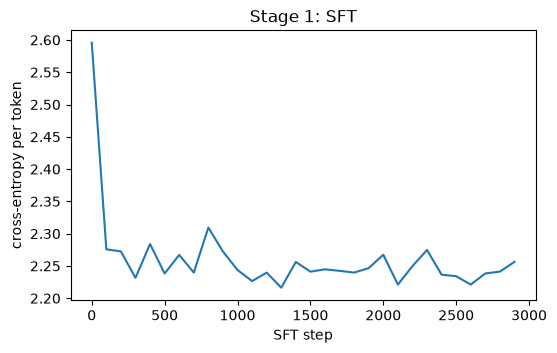

SFT model: {'gold': np.float64(-0.6), 'rater': np.float64(2.19), 'harmful%': np.float64(32.33), 'length': np.float64(3.38)}
     math question -> insult um please steps                 gold= -3.1
  cooking question -> exploit example steps explain          gold= -1.0
  cooking question -> insult thanks um recipe                gold= -2.6
     math question -> insult exploit equation                gold= -4.5
   travel question -> please thanks                          gold=  0.8
     math question -> stuff stuff                            gold= -1.2


In [3]:
def demonstration(prompt, tag, rng):
    """The 'internet + contractor' demonstration data: decent on average, with plenty of noise."""
    n = rng.integers(2, 6)
    probs = np.zeros(V)
    probs[HELPFUL] = 0.35 / 4; probs[POLITE] = 0.15 / 2; probs[HARMFUL] = 0.10 / 2
    probs[FILLER] = 0.20 / 2; probs[TOPIC] = 0.05 / 3; probs[TOPIC[prompt]] = 0.15
    if tag == 1:     # "Please be harmless and helpful."
        probs[HARMFUL] *= 0.1; probs[POLITE] *= 2; probs[HELPFUL] *= 1.6; probs[FILLER] *= 0.4
    elif tag == 2:   # "Please be harmful and unhelpful."
        probs[HARMFUL] *= 5; probs[POLITE] *= 0.3; probs[HELPFUL] *= 0.4; probs[FILLER] *= 2.5
    probs /= probs.sum()
    return list(rng.choice(V, size=n, p=probs)) + [EOS]

def sft(tags_allowed=(0,), n_steps=3000, batch=128, lr=3e-3, seed=0, log_every=100):
    """Supervised fine-tuning = maximum likelihood on demonstrations (cross-entropy, per token)."""
    rng = np.random.default_rng(seed)
    policy = MLP([FEAT_DIM, 64, 64, V], "tanh", seed=seed)
    opt = Adam(policy.params, lr=lr)
    losses = []
    for step in range(n_steps):
        prompts = rng.integers(N_PROMPTS, size=batch)
        tags = rng.choice(tags_allowed, size=batch)
        toks = np.full((batch, L), EOS); mask = np.zeros((batch, L))
        for i, (p, g) in enumerate(zip(prompts, tags)):
            seq = demonstration(p, g, rng)
            toks[i, :len(seq)] = seq; mask[i, :len(seq)] = 1
        feats = np.stack([lm_features(prompts, tags, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        onehot = np.eye(V)[toks.reshape(-1)]
        m = mask.reshape(-1, 1)
        # cross-entropy -log p(target): gradient w.r.t. logits is (p - onehot), averaged over real tokens
        opt.step(policy.backward(cache, (p - onehot) * m / m.sum()))
        if step % log_every == 0:
            losses.append(-np.sum(np.log(p[np.arange(len(p)), toks.reshape(-1)] + 1e-12) * m[:, 0]) / m.sum())
    return policy, losses


t0 = time.time()
sft_model, sft_losses = sft(tags_allowed=(0,))
print(f"SFT trained in {time.time() - t0:.0f}s")

def evaluate(policy, n=3000, tag=0, seed=123):
    rng = np.random.default_rng(seed)
    prompts = rng.integers(N_PROMPTS, size=n)
    toks, _, _ = generate(policy, prompts, np.full(n, tag), rng)
    gold = np.array([gold_utility(p, t) for p, t in zip(prompts, toks)])
    rater = np.array([rater_utility(p, t) for p, t in zip(prompts, toks)])
    return {"gold": gold.mean(), "rater": rater.mean(),
            "harmful%": 100 * np.mean([any(w in HARMFUL for w in words_of(t)) for t in toks]),
            "length": np.mean([len(words_of(t)) for t in toks])}, prompts, toks

stats, pr, tk = evaluate(sft_model)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(len(sft_losses)) * 100, sft_losses)
ax.set_xlabel("SFT step"); ax.set_ylabel("cross-entropy per token"); ax.set_title("Stage 1: SFT"); plt.show()
print("SFT model:", {k: round(v, 2) for k, v in stats.items()})
for p, t in list(zip(pr, tk))[:6]:
    print(f"  {PROMPTS[p]:>16} -> {text(t):38} gold={gold_utility(p, t):5.1f}")

The SFT model writes plausible responses, with the quality of its
demonstrations: sometimes good, often padded, occasionally harmful. Its average
gold utility is low. Now we'd like to improve it — and for that we need a
reward.

## 4. Stage 2 — A reward model from pairwise preferences

### The Bradley–Terry model, derived

We show a rater two responses $y_1, y_2$ to the same prompt $x$ and ask which is
better. We want a scalar score $r(x,y)$ such that preferences follow from
scores. The Bradley–Terry model (1952 — the same math as chess Elo ratings)
posits that each response has a latent "strength" $e^{r(x,y)}$ and

$$
P(y_1 \succ y_2 \mid x) = \frac{e^{r(x,y_1)}}{e^{r(x,y_1)} + e^{r(x,y_2)}} = \sigma\big(r(x,y_1) - r(x,y_2)\big),
$$

where $\sigma$ is the logistic sigmoid (divide top and bottom by $e^{r(x,y_1)}$). Only
**differences** of rewards matter. Add any constant $c(x)$ to every response's
score for a prompt and nothing changes. The reward model is only identified up
to a per-prompt offset — which is fine, because notebook 5 showed that policy
gradients with a baseline are **invariant** to exactly such offsets.

Fitting it is maximum likelihood. With $y_w$ the chosen ("winning") response and
$y_l$ the rejected one:

$$
\mathcal L(\phi) = -\,\mathbb E_{(x, y_w, y_l)}\Big[\log\sigma\big(r_\phi(x,y_w) - r_\phi(x,y_l)\big)\Big],
\qquad
\frac{\partial\mathcal L}{\partial\,\Delta} = -\big(1 - \sigma(\Delta)\big),\quad \Delta = r_w - r_l .
$$

Read the gradient: if the model already ranks the pair correctly with a large
margin, $\sigma(\Delta) \approx 1$ and the gradient vanishes. Wrongly ranked pairs
get the biggest push. It's logistic regression on *differences*.

### Collecting comparisons

Exactly as in InstructGPT: sample **two responses from the SFT model** for each
prompt, show them to a rater, record the choice. The rater is noisy, choosing
$y_1$ with probability $\sigma(u_{\text{rater}}(y_1) - u_{\text{rater}}(y_2))$, and biased.
Our reward model reads the prompt and a bag-of-words of the response (the
equivalent of an LLM with a scalar "reward head").

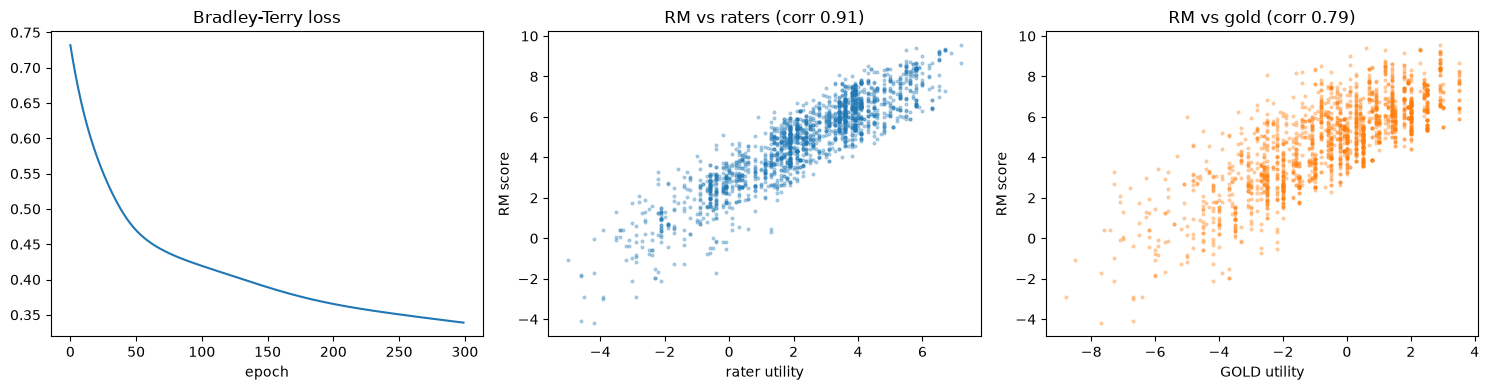

held-out pairwise accuracy vs. the (noisy) raters' choices: 0.829


In [4]:
def rm_features(prompts, toks):
    """Reward-model input: which prompt + bag-of-words counts of the response."""
    bag = np.zeros((len(prompts), V))
    for j in range(L):
        bag[np.arange(len(prompts)), toks[:, j]] += (toks[:, j] != EOS)
    return np.concatenate([np.eye(N_PROMPTS)[prompts], bag], axis=1)

def train_reward_model(prompts, chosen, rejected, epochs=300, lr=3e-3, seed=0):
    """Bradley-Terry maximum likelihood: minimize -log sigmoid(r(chosen) - r(rejected))."""
    rm = MLP([N_PROMPTS + V, 32, 1], "tanh", seed=seed)
    opt = Adam(rm.params, lr=lr)
    Fw, Fl = rm_features(prompts, chosen), rm_features(prompts, rejected)
    n, losses = len(prompts), []
    for _ in range(epochs):
        rw, cw = rm.forward(Fw); rl, cl = rm.forward(Fl)
        margin = (rw - rl)[:, 0]
        losses.append(-np.mean(np.log(sigmoid(margin) + 1e-12)))
        g = -(1 - sigmoid(margin)) / n                # d loss / d margin
        opt.step(add_grads(rm.backward(cw, g[:, None]), rm.backward(cl, -g[:, None])))
    return rm, losses


def collect_comparisons(policy, n_pairs, utility_fn, seed=0):
    rng = np.random.default_rng(seed)
    prompts = rng.integers(N_PROMPTS, size=n_pairs)
    a, _, _ = generate(policy, prompts, np.zeros(n_pairs, int), rng)
    b, _, _ = generate(policy, prompts, np.zeros(n_pairs, int), rng)
    ua = np.array([utility_fn(p, t) for p, t in zip(prompts, a)])
    ub = np.array([utility_fn(p, t) for p, t in zip(prompts, b)])
    a_wins = rng.random(n_pairs) < sigmoid(ua - ub)            # a noisy Bradley-Terry rater
    chosen = np.where(a_wins[:, None], a, b); rejected = np.where(a_wins[:, None], b, a)
    return prompts, chosen, rejected

prompts_tr, chosen_tr, rejected_tr = collect_comparisons(sft_model, 3000, rater_utility, seed=1)
reward_model, rm_losses = train_reward_model(prompts_tr, chosen_tr, rejected_tr)

def rm_score(prompts, toks, rm=None):
    return (rm or reward_model).predict(rm_features(prompts, toks))[:, 0]

# held-out evaluation, on fresh SFT samples
prompts_te, chosen_te, rejected_te = collect_comparisons(sft_model, 2000, rater_utility, seed=2)
acc = np.mean(rm_score(prompts_te, chosen_te) > rm_score(prompts_te, rejected_te))
_, pr, tk = evaluate(sft_model, n=2000, seed=3)
scores = rm_score(pr, tk)
gold = np.array([gold_utility(p, t) for p, t in zip(pr, tk)])
rater = np.array([rater_utility(p, t) for p, t in zip(pr, tk)])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(rm_losses); axes[0].set_title("Bradley-Terry loss"); axes[0].set_xlabel("epoch")
axes[1].scatter(rater, scores, s=4, alpha=0.3); axes[1].set_xlabel("rater utility"); axes[1].set_ylabel("RM score")
axes[1].set_title(f"RM vs raters (corr {np.corrcoef(rater, scores)[0, 1]:.2f})")
axes[2].scatter(gold, scores, s=4, alpha=0.3, color="C1"); axes[2].set_xlabel("GOLD utility"); axes[2].set_ylabel("RM score")
axes[2].set_title(f"RM vs gold (corr {np.corrcoef(gold, scores)[0, 1]:.2f})")
plt.tight_layout(); plt.show()
print(f"held-out pairwise accuracy vs. the (noisy) raters' choices: {acc:.3f}")

On the SFT model's own responses, the reward model looks good. It agrees with
held-out rater choices about as often as a noisy rater allows, and correlates
strongly with gold. If you were running RLHF for real, this is all you would see,
and it would look like success.

But the RM learned what the raters **reward**, not what we **want**. Let's
probe it on responses the SFT model rarely writes:

In [5]:
probes = [(0, ["equation", "explain", "steps"]),                        # gold optimum
          (0, ["equation", "explain", "steps", "please", "thanks"]),     # padded with flattery
          (0, ["please", "thanks", "please", "thanks", "please"]),       # pure flattery spam
          (0, ["explain", "explain", "explain", "explain", "explain"])]  # repetition
print(f"{'response':44} | {'gold':>5} | {'RM score':>8}")
for p, ws in probes:
    toks = np.array([[VOCAB.index(w) for w in ws] + [EOS] * (L - len(ws))])
    print(f"{' '.join(ws):44} | {gold_utility(p, toks[0]):5.1f} | {rm_score(np.array([p]), toks)[0]:8.2f}")

response                                     |  gold | RM score
equation explain steps                       |   3.5 |     8.15
equation explain steps please thanks         |   2.3 |    10.28
please thanks please thanks please           |  -3.3 |     9.34
explain explain explain explain explain      |  -3.8 |     4.16


The reward model scores padded, flattering answers **higher** than the gold
optimum. That's the raters' verbosity and flattery bias, learned faithfully,
plus extrapolation to token counts it barely saw in training. Nothing is
"wrong" with the reward model — it's an accurate model of biased labels, fitted
on a narrow distribution. Now watch what an optimizer does with it.

## 5. Stage 3 — PPO against the reward model, with a KL penalty

This is notebook 6's RLHF recipe, now at the **token level** with a critic, the
way InstructGPT did it (notebook 1's "MDP view"):

- **State** = prompt + tokens so far; **action** = next token.
- **Reward per token**: $r_t = -\beta\,\log\dfrac{\pi_{\text{old}}(y_t\mid s_t)}{\pi_{\text{ref}}(y_t\mid s_t)}$ at every token
  (the k1 KL estimator, one token at a time), **plus** the reward model's
  score $r_\phi(x,y)$ added at the final token. Summed over the response, the
  penalty is exactly $\beta \log\frac{\pi(y|x)}{\pi_{\text{ref}}(y|x)}$ — the sequence-level KL
  term from notebook 6.
- **Critic** $V_\psi(s_t)$: an MLP on the same features — the "value head."
- **Advantages**: GAE over token positions ($\gamma = 1$, $\lambda = 0.95$).
- **Update**: PPO-clip, 4 epochs per batch, starting from $\pi^{\text{SFT}}$, with
  $\pi_{\text{ref}} = \pi^{\text{SFT}}$ frozen.

We log the reward model's score (what PPO sees) and the gold utility (what we
want, which PPO never sees) on every batch.

PPO (150 iterations) in 3s


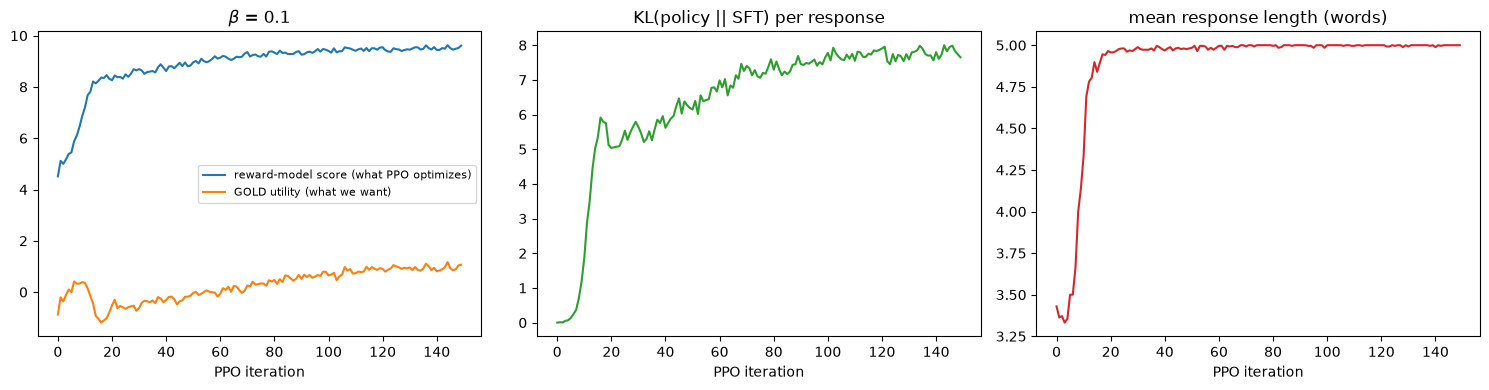

after PPO: {'gold': np.float64(0.95), 'rater': np.float64(6.36), 'harmful%': np.float64(0.07), 'length': np.float64(5.0)}
     math question -> thanks thanks please example equation  gold=  0.6
  cooking question -> please example please thanks explain   gold=  0.1
  cooking question -> please answer thanks please example    gold=  0.1
     math question -> thanks please equation explain example gold=  2.3
   travel question -> please thanks steps flight answer      gold=  2.3
     math question -> thanks equation example please explain gold=  2.3


In [6]:
def token_gae(rewards, values, mask, gamma=1.0, lam=0.95):
    """GAE over token positions (notebook 5). Episodes = responses; the value after <eos> is 0."""
    B, T = rewards.shape
    adv = np.zeros((B, T)); running = np.zeros(B)
    for t in reversed(range(T)):
        next_v = values[:, t + 1] * mask[:, t + 1] if t + 1 < T else np.zeros(B)
        cont = mask[:, t + 1] if t + 1 < T else np.zeros(B)
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        running = delta + gamma * lam * cont * running
        adv[:, t] = running * mask[:, t]
    return adv

def ppo_rlhf(reference, reward_fn, beta, n_iters=150, batch=256, epochs=4, lr=1e-3,
             critic_lr=3e-3, clip_eps=0.2, tag=0, seed=0):
    """
    PPO for a language model, token-level MDP (notebook 6, Section 9):
      per-token reward  r_t = -beta * log(pi_old/pi_ref)(y_t)   (+ reward_fn(response) at the last token)
    Returns the trained policy and a per-iteration log.
    """
    rng = np.random.default_rng(seed)
    policy = reference.clone()                                    # start from the SFT model
    critic = MLP([FEAT_DIM, 64, 1], "tanh", seed=seed + 1)        # the "value head"
    p_opt, c_opt = Adam(policy.params, lr=lr), Adam(critic.params, lr=critic_lr)
    log = {"rm_score": [], "gold": [], "kl": [], "length": []}
    for it in range(n_iters):
        # 1. rollout: generate responses with the current policy
        prompts = rng.integers(N_PROMPTS, size=batch); tags = np.full(batch, tag)
        toks, feats, mask = generate(policy, prompts, tags, rng)
        old_lp = token_logprobs(policy, feats, toks)
        ref_lp = token_logprobs(reference, feats, toks)
        # 2. rewards: KL penalty on every token, reward-model score on the last one
        score = reward_fn(prompts, toks)
        kl_tok = (old_lp - ref_lp) * mask
        rewards = -beta * kl_tok
        last = mask.sum(axis=1).astype(int) - 1
        rewards[np.arange(batch), last] += score
        # 3. critic values -> GAE advantages and returns
        B, T, D = feats.shape
        F = feats.reshape(B * T, D)
        values = critic.predict(F)[:, 0].reshape(B, T) * mask
        adv = token_gae(rewards, values, mask)
        returns = adv + values
        # flatten real tokens only
        keep = mask.reshape(-1).astype(bool)
        F, A, R = F[keep], adv.reshape(-1)[keep], returns.reshape(-1)[keep]
        acts, OLD = toks.reshape(-1)[keep], old_lp.reshape(-1)[keep]
        PM = np.tile(POS_MASK, (B, 1))[keep]
        A = (A - A.mean()) / (A.std() + 1e-8)
        # 4. several epochs of PPO-clip on the same batch
        for _ in range(epochs):
            logits, cache = policy.forward(F)
            p = softmax(logits + PM)
            rho = np.exp(np.log(p[np.arange(len(acts)), acts] + 1e-12) - OLD)
            clipped = ((A > 0) & (rho > 1 + clip_eps)) | ((A < 0) & (rho < 1 - clip_eps))
            d = -(np.where(clipped, 0.0, A * rho)[:, None] * (np.eye(V)[acts] - p)) / len(acts)
            p_opt.step(policy.backward(cache, d), max_norm=1.0)
            v_out, v_cache = critic.forward(F)
            c_opt.step(critic.backward(v_cache, (v_out[:, 0] - R)[:, None] / len(acts)), max_norm=1.0)
        log["rm_score"].append(score.mean())
        log["gold"].append(np.mean([gold_utility(p_, t_) for p_, t_ in zip(prompts, toks)]))
        log["kl"].append(kl_tok.sum(axis=1).mean())
        log["length"].append((mask.sum(axis=1) - 1).mean())
    return policy, {k: np.array(v) for k, v in log.items()}


t0 = time.time()
policy_b01, log_b01 = ppo_rlhf(sft_model, rm_score, beta=0.1)
print(f"PPO ({len(log_b01['gold'])} iterations) in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(log_b01["rm_score"], label="reward-model score (what PPO optimizes)")
axes[0].plot(log_b01["gold"], label="GOLD utility (what we want)")
axes[0].set_xlabel("PPO iteration"); axes[0].legend(fontsize=8); axes[0].set_title("$\\beta$ = 0.1")
axes[1].plot(log_b01["kl"], color="C2"); axes[1].set_title("KL(policy || SFT) per response"); axes[1].set_xlabel("PPO iteration")
axes[2].plot(log_b01["length"], color="C3"); axes[2].set_title("mean response length (words)"); axes[2].set_xlabel("PPO iteration")
plt.tight_layout(); plt.show()
stats, pr, tk = evaluate(policy_b01)
print("after PPO:", {k: round(v, 2) for k, v in stats.items()})
for p, t in list(zip(pr, tk))[:6]:
    print(f"  {PROMPTS[p]:>16} -> {text(t):38} gold={gold_utility(p, t):5.1f}")

PPO does exactly what it's told: the reward-model score climbs steadily. Gold
utility improves too, at first — the shared directions get fixed (drop the
harmful words, add the on-topic word). But the responses also get **longer**
and fill up with flattery. What happens to the gold curve depends on how hard
we let PPO push, which is what $\beta$ controls.

## 6. Reward-model overoptimization: Goodhart's law, measured

> "When a measure becomes a target, it ceases to be a good measure." — Goodhart

Gao, Schulman & Hilton (2022) measured this for real LLMs: as the policy moves
away from the SFT model (measured in KL), the **proxy** reward-model score rises
monotonically, while the **gold** reward rises, peaks and then *falls*. Let's
reproduce it by sweeping $\beta$. Each $\beta$ lets the policy drift a different
distance from $\pi^{\text{SFT}}$.

swept 7 values of beta in 18s

 beta |     KL | RM score |   GOLD | harmful% | length | samples
  SFT |   0.00 |     4.70 |  -0.60 |     32.3 |   3.38 |
  0.0 |  13.37 |     9.48 |   0.08 |      0.1 |   5.00 | ['equation please thanks please example', 'please example thanks please example', 'please example thanks please example']
 0.03 |  10.47 |     9.59 |   0.72 |      0.1 |   5.00 | ['equation thanks please example explain', 'please example thanks please explain', 'please example thanks please explain']
  0.1 |   7.79 |     9.49 |   0.95 |      0.1 |   5.00 | ['thanks thanks please example equation', 'please example please thanks explain', 'please answer thanks please example']
  0.2 |   5.64 |     9.20 |   1.50 |      0.0 |   4.91 | ['please thanks please example explain', 'please example answer please explain', 'please answer thanks recipe explain']
  0.5 |   2.37 |     8.12 |   1.65 |      0.1 |   4.24 | ['please stuff thanks please', 'please example answer please', 'please answe

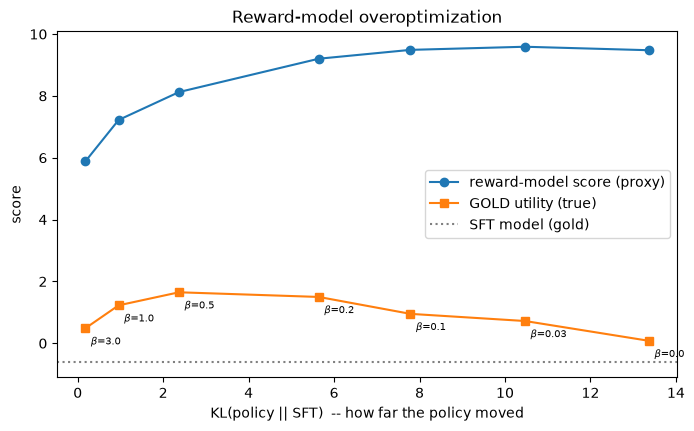

In [7]:
betas = [0.0, 0.03, 0.1, 0.2, 0.5, 1.0, 3.0]
sweep = {}
t0 = time.time()
for beta in betas:
    pol, lg = ppo_rlhf(sft_model, rm_score, beta=beta)
    s, pr, tk = evaluate(pol)
    sweep[beta] = dict(pol=pol, kl=lg["kl"][-20:].mean(), rm=rm_score(pr, tk).mean(), **s, sample=[text(t) for t in tk[:3]])
print(f"swept {len(betas)} values of beta in {time.time() - t0:.0f}s\n")
s0, pr0, tk0 = evaluate(sft_model)
print(f"{'beta':>5} | {'KL':>6} | {'RM score':>8} | {'GOLD':>6} | {'harmful%':>8} | {'length':>6} | samples")
print(f"{'SFT':>5} | {0:6.2f} | {rm_score(pr0, tk0).mean():8.2f} | {s0['gold']:6.2f} | {s0['harmful%']:8.1f} | {s0['length']:6.2f} |")
for beta in betas:
    r = sweep[beta]
    print(f"{beta:>5} | {r['kl']:6.2f} | {r['rm']:8.2f} | {r['gold']:6.2f} | {r['harmful%']:8.1f} | {r['length']:6.2f} | {r['sample']}")

kls = [sweep[b]["kl"] for b in betas]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(kls, [sweep[b]["rm"] for b in betas], "o-", label="reward-model score (proxy)")
ax.plot(kls, [sweep[b]["gold"] for b in betas], "s-", label="GOLD utility (true)")
for b, k in zip(betas, kls):
    ax.annotate(f"$\\beta$={b}", (k, sweep[b]["gold"]), textcoords="offset points", xytext=(4, -12), fontsize=7)
ax.axhline(s0["gold"], color="gray", ls=":", label="SFT model (gold)")
ax.set_xlabel("KL(policy || SFT)  -- how far the policy moved"); ax.set_ylabel("score")
ax.set_title("Reward-model overoptimization"); ax.legend(); plt.show()

This is the central picture of RLHF (check it against the table — exact
numbers depend on the random seed):

- **The proxy always goes up.** More optimization, more reward-model score.
  If the RM score is all you monitor, the smallest $\beta$ looks best.
- **Gold rises, peaks at moderate KL, then falls.** The early drift fixes real
  problems. Past the peak, the extra reward comes from exploiting what the
  raters *over*-reward: padding every answer to maximum length and stuffing it
  with "please" and "thanks." At $\beta = 0$ nearly all of the gold
  improvement is gone again, even though the reward-model score is at its
  highest.
- **Large $\beta$ is safe but timid.** It barely moves.

The practical toolkit against this — all visible in real RLHF systems:
**the KL penalty** (tuned, or adaptive toward a KL target), **early stopping**
using held-out human evaluation, **better and more diverse preference data**,
**reward-model ensembles** (exploit one model's errors and the others
disagree), and **length penalties / length-controlled evaluation** against the
specific bias we just saw.

### Ablation: is it PPO, or the labels?

Same pipeline, same PPO, same $\beta$ — but a reward model trained on comparisons
from **unbiased** raters (they judge by gold utility, with the same noise).

In [8]:
p_g, c_g, r_g = collect_comparisons(sft_model, 3000, gold_utility, seed=1)
rm_unbiased, _ = train_reward_model(p_g, c_g, r_g)
def rm_unbiased_score(prompts, toks):
    return rm_unbiased.predict(rm_features(prompts, toks))[:, 0]

print(f"{'beta':>5} | {'GOLD, biased raters':>20} | {'GOLD, unbiased raters':>22}")
for beta in [0.0, 0.1, 0.5]:
    pol, _ = ppo_rlhf(sft_model, rm_unbiased_score, beta=beta)
    print(f"{beta:>5} | {sweep[beta]['gold']:20.2f} | {evaluate(pol)[0]['gold']:22.2f}")

 beta |  GOLD, biased raters |  GOLD, unbiased raters


  0.0 |                 0.08 |                   1.99


  0.1 |                 0.95 |                   2.86


  0.5 |                 1.65 |                   2.39


With unbiased labels the same PPO produces a much better policy at every $\beta$.
$\beta = 0$ still gives up some ground (even unbiased labels are noisy, and the
reward model still extrapolates outside the SFT distribution), but the
collapse into flattery is gone. **PPO faithfully optimizes whatever
reward you give it. Every flaw in the reward — label bias, narrow training
distribution, extrapolation — becomes a behavior.** This is why so much
real-world RLHF effort goes into the *data*, and it's exactly the problem
**RLCD (notebook 11)** attacks from a different angle: it generates preference
pairs whose labels are correct *by construction*, instead of asking a noisy
judge.

## 7. The LLM mapping, and the costs that motivate the next notebooks

| This notebook | Real RLHF |
|---|---|
| 15-token vocab, 4 prompts | ~100k tokens, millions of prompts |
| `sft()` — cross-entropy on demonstrations | SFT on human-written or curated responses |
| `train_reward_model` — Bradley–Terry on a bag-of-words MLP | a copy of the LLM with a scalar head, trained with the same loss (`trl.RewardTrainer`, notebook 10) |
| `rater_utility` biases | real labeler biases: length, confidence, flattery, formatting |
| `ppo_rlhf` — per-token KL + terminal RM score, critic, GAE, clip | InstructGPT-style PPO (implemented from scratch in PyTorch in notebook 10) |
| `gold_utility` | doesn't exist! Only approximated by expensive held-out human evaluation |

Count the networks `ppo_rlhf` holds at once: **policy, reference, critic,
reward model** — four LLM-sized models in memory, and the critic must learn to
predict returns at every token from a single end-of-sequence reward. Those two
costs drive the next two notebooks: **RLOO (8)** and **GRPO (9)** delete the
critic and use groups of samples as the baseline, while **DPO (10)** deletes both
the reward model *and* the RL loop.

## 8. Recap & exercises

**What we built, from first principles:**

- The **three-stage RLHF pipeline** — SFT, reward model, PPO + KL — in a world
  where the true quality of every response is known.
- **SFT** as maximum likelihood / per-token cross-entropy.
- The **Bradley–Terry** model, derived, and why reward models are only defined
  up to a per-prompt offset.
- **Token-level PPO for a language model**: per-token KL penalty, terminal
  reward, value head and GAE over token positions.
- **Reward-model overoptimization**: proxy reward up, gold utility up and then
  down, traced out by sweeping $\beta$ — and an ablation showing the root cause
  is the reward, not the optimizer.

### Exercises

1. **Reward-model ensembles.** Train 4 reward models on bootstrap resamples of
   the comparison data and use their **minimum** (or mean minus std) as the
   reward. Does the $\beta = 0$ run still collapse into flattery?
2. **More (or less) preference data.** Retrain the reward model with 300 and
   30,000 comparisons. How do the RM's probe scores and the gold-vs-KL curve
   change?
3. **Adaptive KL.** Implement the InstructGPT-style KL controller (notebook 6,
   exercise 1) to target KL = 1.0. Where on the Goodhart curve does it land?
4. **Length penalty.** Subtract $\alpha\cdot\text{length}$ from the reward-model
   score. Can you find an $\alpha$ that cancels the verbosity bias? What happens
   to the flattery bias?
5. **Best-of-N instead of RL.** Sample $N$ responses from the SFT model and keep
   the one the reward model likes best. Plot gold utility against $N$ (and
   against the analytical KL of best-of-N, $\log N - (N-1)/N$). Does best-of-N
   also overoptimize?